In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from te2rules.explainer import ModelExplainer

In [2]:
TRAIN_MODEL = True

TRAIN_CSV = '../../results/metrics.csv'
VAL_CSV = '../../results/codescene_metrics.csv'

MODEL_OUTPUT_DIR = 'saved_model/'
MODEL_DIR = 'saved_model/'
OUTPUT_PNG = '../../results/acts_validation_predictions.png'

In [3]:


def engineer_features(df, target_col='is_high_risk'):
    df_fe = df.copy()

    df_fe['operator_operand_ratio'] = df_fe['halstead_operators'] / \
        (df_fe['halstead_operands'] + 1)
    df_fe['sloc_per_function'] = df_fe['loc_sloc'] / \
        (df_fe['nom_functions'] + 1)
    df_fe['complexity_per_function'] = df_fe['wmc_cyclomatic'] / \
        (df_fe['nom_functions'] + 1)
    df_fe['effort_per_volume'] = df_fe['halstead_effort'] / \
        (df_fe['halstead_volume'] + 1)
    df_fe['avg_exit_per_fn'] = df_fe['nexits_exit_sum'] / \
        (df_fe['nom_functions'] + 1)
    df_fe['cognitive_per_cyclomatic'] = df_fe['cognitive_sum'] / \
        (df_fe['cyclomatic_cyclomatic_sum'] + 1)

    for col in ['halstead_volume', 'halstead_effort', 'loc_sloc', 'loc_ploc', 'halstead_operators', 'halstead_operands']:
        df_fe[f'{col}_log'] = np.log1p(df_fe[col])

    df_fe['repo'] = df_fe['file_path'].str.split('__').str[0]

    exclude_cols = ['file_path', 'repo', target_col]
    feature_cols = [col for col in df_fe.columns if col not in exclude_cols]

    df_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_fe.dropna(inplace=True)

    X = df_fe[feature_cols].copy()
    X = X.select_dtypes(include=[np.number])
    X = X.fillna(X.median())

    y = df_fe[target_col].astype(str).str.lower()

    key_features = ['halstead_difficulty', 'halstead_effort', 'halstead_volume',
                    'wmc_cyclomatic', 'cyclomatic_cyclomatic', 'loc_sloc',
                    'nom_functions', 'cognitive']
    existing_features = [f for f in key_features if f in X.columns]

    poly = PolynomialFeatures(
        degree=2, include_bias=False, interaction_only=False)
    X_key = X[existing_features].copy()
    poly_features = poly.fit_transform(X_key)
    poly_feature_names = poly.get_feature_names_out(existing_features)

    for i, name in enumerate(poly_feature_names):
        clean_name = name.replace(' ', '_')
        X[f'poly_{clean_name}'] = poly_features[:, i]

    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X = X.fillna(X.median())

    return X, y, poly

In [4]:
def select_features(X, y, var_thresh=None, selector=None):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
    X_selected = X.drop(columns=to_drop)

    if var_thresh is None:
        var_thresh = VarianceThreshold(threshold=0.01)
        X_transformed = var_thresh.fit_transform(X_selected)
    else:
        X_transformed = var_thresh.transform(X_selected)

    X_selected = pd.DataFrame(
        X_transformed,
        columns=X_selected.columns[var_thresh.get_support()],
        index=X_selected.index
    )

    X_selected.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_selected = X_selected.fillna(X_selected.median())
    to_drop_nan = X_selected.columns[X_selected.isna().all()]
    if len(to_drop_nan) > 0:
        X_selected = X_selected.drop(columns=to_drop_nan)

    best_k = min(30, X_selected.shape[1])
    if selector is None:
        selector = SelectKBest(f_classif, k=best_k)
        X_final = pd.DataFrame(
            selector.fit_transform(X_selected, y),
            columns=[X_selected.columns[i]
                     for i in selector.get_support(indices=True)],
            index=X_selected.index
        )
    else:
        X_final = pd.DataFrame(
            selector.transform(X_selected),
            columns=[X_selected.columns[i]
                     for i in selector.get_support(indices=True)],
            index=X_selected.index
        )

    return X_final, var_thresh, selector

Training data: 9667 samples

CLASS DISTRIBUTION (TRAINING DATA)
is_high_risk
true     5437
false    3988
Name: count, dtype: int64

Class imbalance ratio: 1.36:1


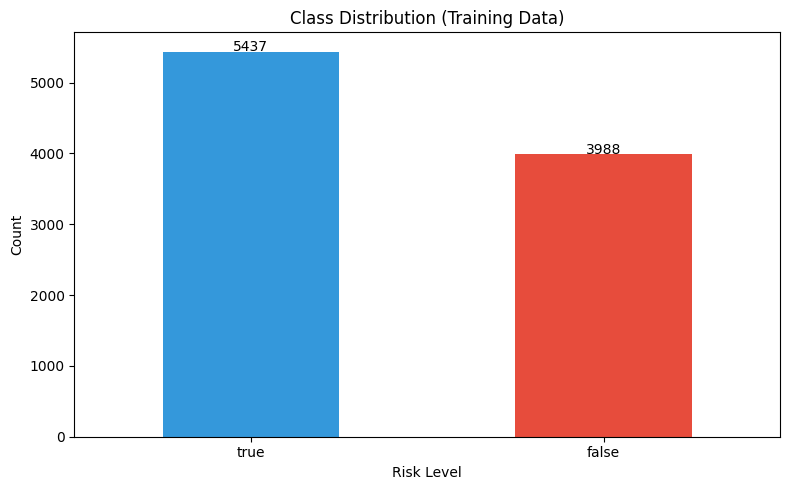

Class distribution saved to class_distribution.png
Target classes: ['false' 'true']
Feature engineered shape: (9425, 100)


In [5]:
if TRAIN_MODEL:
    le = LabelEncoder()

    df_train = pd.read_csv(TRAIN_CSV)
    print(f"Training data: {df_train.shape[0]} samples")

    X_train, y_train, poly = engineer_features(df_train)

    print("\n" + "="*60)
    print("CLASS DISTRIBUTION (TRAINING DATA)")
    print("="*60)
    value_counts = y_train.value_counts()
    print(value_counts)
    print(f"\nClass imbalance ratio: {value_counts.max() / value_counts.min():.2f}:1")

    plt.figure(figsize=(8, 5))
    value_counts.plot(kind='bar', color=['#3498db', '#e74c3c'])
    plt.title('Class Distribution (Training Data)')
    plt.xlabel('Risk Level')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    for i, v in enumerate(value_counts):
        plt.text(i, v + 10, str(v), ha='center')
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150)
    plt.show()
    print("Class distribution saved to class_distribution.png")
    y_train_encoded = le.fit_transform(y_train.astype(str))
    print(f"Target classes: {le.classes_}")
    print(f"Feature engineered shape: {X_train.shape}")

In [6]:
if TRAIN_MODEL:
    X_train_final, var_thresh, selector = select_features(
        X_train, y_train_encoded)
    print(f"Final feature count: {X_train_final.shape[1]}")
    print(f"Selected features: {list(X_train_final.columns)}")
    print(f"Training FE columns: {sorted(X_train_final.columns.tolist())}")

Final feature count: 30
Selected features: ['nargs_fn_nargs_sum', 'nargs_closure_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_max', 'nexits_exit', 'nexits_exit_sum', 'nexits_exit_max', 'cognitive', 'cognitive_sum', 'cognitive_avg', 'cognitive_max', 'cyclomatic_cyclomatic', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_max', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_difficulty', 'halstead_effort', 'loc_blank', 'operator_operand_ratio', 'cognitive_per_cyclomatic', 'halstead_volume_log', 'poly_halstead_difficulty_cyclomatic_cyclomatic', 'poly_halstead_effort_nom_functions', 'poly_halstead_effort_cognitive', 'poly_halstead_volume_cyclomatic_cyclomatic', 'poly_halstead_volume_loc_sloc', 'poly_cyclomatic_cyclomatic_loc_sloc']
Training FE columns: ['cognitive', 'cognitive_avg', 'cognitive_max', 'cognitive_per_cyclomatic', 'cognitive_sum', 'cyclomatic_cyclomatic', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_max'

In [7]:
if TRAIN_MODEL:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("\n" + "="*60)
    print("RANDOM FOREST WITH 5-FOLD CROSS-VALIDATION")
    print("="*60)

    rf_param_grid = {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 4, 8],
        'max_features': ['sqrt', 'log2'],
        'class_weight': ['balanced', {0: 1, 1: 1.5}]
    }

    rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True)
    rf_grid_search = GridSearchCV(
        rf_clf, rf_param_grid, cv=cv, scoring='f1', n_jobs=-1
    )
    rf_grid_search.fit(X_train_final, y_train_encoded)

    print("Best Random Forest params:", rf_grid_search.best_params_)
    print("Best CV F1 score:", rf_grid_search.best_score_)

    rf_clf = rf_grid_search.best_estimator_

    cv_accuracy = cross_val_score(
        rf_clf, X_train_final, y_train_encoded, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(
        rf_clf, X_train_final, y_train_encoded, cv=cv, scoring='precision')
    cv_recall = cross_val_score(
        rf_clf, X_train_final, y_train_encoded, cv=cv, scoring='recall')
    cv_f1 = cross_val_score(
        rf_clf, X_train_final, y_train_encoded, cv=cv, scoring='f1')

    print("\nRandom Forest 5-Fold Cross-Validation Results:")
    print(f"Accuracy:  {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}")
    print(f"Precision: {cv_precision.mean():.4f} +/- {cv_precision.std():.4f}")
    print(f"Recall:    {cv_recall.mean():.4f} +/- {cv_recall.std():.4f}")
    print(f"F1 Score:  {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")

    cv_preds = cross_val_predict(rf_clf, X_train_final, y_train_encoded, cv=cv)

    print("\nCross-Validation Confusion Matrix:")
    cv_cm = confusion_matrix(y_train_encoded, cv_preds)
    print(cv_cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cv_cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('RF Cross-Validation Confusion Matrix')
    plt.tight_layout()
    plt.savefig('rf_cv_confusion_matrix.png', dpi=150)
    plt.show()
    print("RF CV confusion matrix saved to rf_cv_confusion_matrix.png")

    rf_clf.fit(X_train_final, y_train_encoded)
    print(f"\nOOB Score: {rf_clf.oob_score_:.4f}")

    rf_feature_importance = pd.DataFrame({
        'feature': X_train_final.columns,
        'importance': rf_clf.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\nRF Feature Importances (top 15):")
    print(rf_feature_importance.head(15))
    print(f"Target classes: {le.classes_}")

    os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
    joblib.dump(rf_clf, f'{MODEL_OUTPUT_DIR}/rf_model.joblib')
    joblib.dump(le, f'{MODEL_OUTPUT_DIR}/label_encoder.joblib')
    joblib.dump(var_thresh, f'{MODEL_OUTPUT_DIR}/var_thresh.joblib')
    joblib.dump(selector, f'{MODEL_OUTPUT_DIR}/selector.joblib')
    with open(f'{MODEL_OUTPUT_DIR}/selected_features.txt', 'w') as f:
        f.write('\n'.join(X_train_final.columns))

    print(f"\nModel saved to {MODEL_OUTPUT_DIR}")


RANDOM FOREST WITH 5-FOLD CROSS-VALIDATION


Process LokyProcess-4:
Traceback (most recent call last):
  File "/home/art/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/art/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py", line 505, in _process_worker
    _process_reference_size = _get_memory_usage(pid, force_gc=True)
  File "/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py", line 110, in _get_memory_usage
    gc.collect()
    ~~~~~~~~~~^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
print("\n" + "="*60)
print("RANDOM FOREST RULE EXTRACTION (te2rules)")
print("="*60)
#
# explainer = ModelExplainer(
#     model=rf_clf,
#     feature_names=list(X_train_final.columns)
# )
# rf_rules = explainer.explain(X_train_final.values, y_train_encoded)
# print("\nExtracted Rules from Random Forest:")
# print(rf_rules)

In [ ]:
print("\n" + "="*60)
print("DECISION TREE WITH 5-FOLD CROSS-VALIDATION")
print("="*60)

dt_param_grid = {
    'max_depth': [5, 7],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'criterion': ['entropy'],
    'class_weight': [{0: 1, 1: 2}]
}

dt_clf = DecisionTreeClassifier(random_state=42)
dt_grid_search = GridSearchCV(
    dt_clf, dt_param_grid, cv=cv, scoring='f1', n_jobs=-1
)
dt_grid_search.fit(X_train_final, y_train_encoded)

print("Best Decision Tree params:", dt_grid_search.best_params_)
print("Best CV F1:", dt_grid_search.best_score_)

dt_clf = dt_grid_search.best_estimator_

dt_cv_accuracy = cross_val_score(
    dt_clf, X_train_final, y_train_encoded, cv=cv, scoring='accuracy')
dt_cv_precision = cross_val_score(
    dt_clf, X_train_final, y_train_encoded, cv=cv, scoring='precision')
dt_cv_recall = cross_val_score(
    dt_clf, X_train_final, y_train_encoded, cv=cv, scoring='recall')
dt_cv_f1 = cross_val_score(dt_clf, X_train_final,
                           y_train_encoded, cv=cv, scoring='f1')

print("\nDecision Tree 5-Fold Cross-Validation Results:")
print(f"Accuracy:  {dt_cv_accuracy.mean():.4f} +/- {dt_cv_accuracy.std():.4f}")
print(f"Precision: {dt_cv_precision.mean():.4f} +/- {dt_cv_precision.std():.4f}")
print(f"Recall:    {dt_cv_recall.mean():.4f} +/- {dt_cv_recall.std():.4f}")
print(f"F1 Score:  {dt_cv_f1.mean():.4f} +/- {dt_cv_f1.std():.4f}")

dt_cv_preds = cross_val_predict(dt_clf, X_train_final, y_train_encoded, cv=cv)
dt_cv_cm = confusion_matrix(y_train_encoded, dt_cv_preds)
print("\nDT CV Confusion Matrix:")
print(dt_cv_cm)

dt_clf.fit(X_train_final, y_train_encoded)
dt_feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': dt_clf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nDT Feature Importances (top 15):")
print(dt_feature_importance.head(15))

In [ ]:
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(dt_clf, feature_names=list(X_train_final.columns),
          class_names=list(le.classes_), filled=True, ax=ax, max_depth=4)
plt.title("Decision Tree Classifier (max_depth=4 for readability)")
plt.tight_layout()
plt.savefig("decision_tree_optimized.png", dpi=150, bbox_inches='tight')
plt.show()
print("Tree visualization saved to decision_tree_optimized.png")

In [ ]:
print("\n" + "="*60)
print("EXTRACTING DECISION TREE RULES (INTERPRETABLE)")
print("="*60)

tree_rules = export_text(
    dt_clf, feature_names=list(X_train_final.columns), max_depth=4)
print("Decision Tree Rules (first 4 levels):")
print(tree_rules)

In [ ]:
print("\n" + "="*60)
print("MODEL COMPARISON (CV-BASED)")
print("="*60)

plt.figure(figsize=(12, 6))
models = ['Random Forest', 'Decision Tree']
cv_f1_scores = [cv_f1.mean(), dt_cv_f1.mean()]
colors = ['#3498db', '#e74c3c']

plt.bar(models, cv_f1_scores, color=colors)
plt.ylabel('F1 Score')
plt.title('Model Comparison (CV F1 Score)')
plt.ylim(0, 1)
for i, v in enumerate(cv_f1_scores):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Original features: {X_train.shape[1]}")
print(f"Enhanced features: {X_train.shape[1]}")
print(f"Selected features: {X_train_final.shape[1]}")
print(f"\nRandom Forest CV F1: {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")
print(f"Decision Tree CV F1: {dt_cv_f1.mean():.4f} +/- {dt_cv_f1.std():.4f}")

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)

print("\nFinal Feature Set:")
print(X_train_final.columns.tolist())

In [ ]:
df_val = pd.read_csv(VAL_CSV)
print(f"Validation data: {df_val.shape[0]} samples")

X_val, y_val, _ = engineer_features(df_val)
print(f"Validation feature engineered: {X_val.shape}")

In [ ]:
print("\n" + "="*60)
print("VALIDATION ON HELD-OUT DATASET")
print("="*60)

rf_clf = joblib.load(f'{MODEL_DIR}/rf_model.joblib')
le = joblib.load(f'{MODEL_DIR}/label_encoder.joblib')

print(f"Target classes: {le.classes_}")

with open(f'{MODEL_DIR}/selected_features.txt', 'r') as f:
    selected_feature_names = [line.strip() for line in f.readlines()]

# Select the same columns used in training - no sklearn selector needed
X_val_final = X_val[selected_feature_names]

print(f"Validation features: {X_val_final.shape}")

y_pred = rf_clf.predict(X_val_final)
y_prob = rf_clf.predict_proba(X_val_final)[:, 1]

y_val_true_enc = le.transform(y_val.values)
acc = accuracy_score(y_val_true_enc, y_pred)
prec = precision_score(y_val_true_enc, y_pred, zero_division=0)
rec = recall_score(y_val_true_enc, y_pred, zero_division=0)
f1 = f1_score(y_val_true_enc, y_pred, zero_division=0)
cm = confusion_matrix(y_val_true_enc, y_pred)

print(f"\nValidation Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Validation Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150)
plt.show()
print(f"Confusion matrix saved to {OUTPUT_PNG}")